# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name:Jomana Mohamed Magdy

ID:58-4193

Tutorial:10

---

Name:Malak Osama Elmahy

ID:58-3344

Tutorial:10

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


## Data Inspection

In [6]:
#We must first inspect the dataset
print("\n Dataset Information:")
df.info()
pd.set_option("display.float_format", "{:.2f}".format)
df.describe()
print("\n Summary Statistics for Numerical Columns:")
display(df.describe().T)
print("\n Summary Statistics for Categorical Columns:")
display(df.describe(include='object').T)
print("\n Missing Values per Column:")
missing_values = df.isnull().sum()
display(missing_values)
print("\nPercentage of Missing Values:")
display((df.isnull().mean() * 100).round(2))
print("\n Checking for Duplicated Rows:")
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
print("\n Preview of First 5 Rows:")
display(df.head())
print("\n Preview of Last 5 Rows:")
display(df.tail())
#Checking columns with null values
df.isnull().sum()
#Checking the unique values for each column
for column in df.columns:
    print(f"{column} : {df[column].unique()}")
    print("====================================")
#Checking the number of unique values for each column
for column in df.columns:
    print(f"{column}: Number of unique values {df[column].nunique()}")
    print("==========================================================")


 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 10957 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ApplicationNumber     10957 non-null  int64 
 1   Age                   10957 non-null  int64 
 2   AnnualIncome          10957 non-null  object
 3   CreditScore           10957 non-null  int64 
 4   EmploymentStatus      10957 non-null  object
 5   EducationLevel        10957 non-null  object
 6   LoanAmount            10957 non-null  object
 7   LoanDuration          10957 non-null  object
 8   MaritalStatus         10957 non-null  object
 9   NumberOfDependents    10957 non-null  int64 
 10  HomeOwnershipStatus   10957 non-null  object
 11  BankruptcyHistory     10957 non-null  int64 
 12  LoanPurpose           10957 non-null  object
 13  PreviousLoanDefaults  10957 non-null  int64 
 14  MonthlyLoanPayment    10957 non-null  object
 15  MonthlyIncome     

,count,mean,std,min,25%,50%,75%,max
ApplicationNumber,10957.00,20479.42,5761.87,10502.00,15484.00,20473.00,25421.00,30497.00
Age,10957.00,39.65,11.60,18.00,31.00,40.00,48.00,80.00
CreditScore,10957.00,571.84,50.85,343.00,541.00,579.00,609.00,712.00
NumberOfDependents,10957.00,1.53,1.39,0.00,0.00,1.00,3.00,5.00
BankruptcyHistory,10957.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PreviousLoanDefaults,10957.00,0.10,0.30,0.00,0.00,0.00,0.00,1.00
JobTenure,10957.00,5.00,2.22,0.00,3.00,5.00,6.00,16.00



 Summary Statistics for Categorical Columns:


,count,unique,top,freq
AnnualIncome,10957,10002,"$15,000.00",331
EmploymentStatus,10957,3,Employed,9323
EducationLevel,10957,5,Bachelor,3327
LoanAmount,10957,9547,"$14,075.00",6
LoanDuration,10957,10,60 months,2190
MaritalStatus,10957,4,Married,5442
HomeOwnershipStatus,10957,4,Mortgage,4297
LoanPurpose,10957,5,Home Improvement,3314
MonthlyLoanPayment,10957,10225,$556.08,4
MonthlyIncome,10957,9986,"$1,250.00",336



 Missing Values per Column:


...


 Checking for Duplicated Rows:
Number of duplicate rows: 0

 Preview of First 5 Rows:


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No
7,20270,18,"$44,425.00",574,Employed,High School,"$33,360.00",24 months,Married,1,Mortgage,0,Home Improvement,0,"$1,390.00","$3,702.08",7,No



 Preview of Last 5 Rows:


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
19989,24447,79,"$60,888.00",712,Employed,Master,"$11,101.00",24 months,Single,4,Own,0,Home Improvement,0,$462.54,"$5,074.00",3,Yes
19990,21965,79,"$39,536.00",546,Employed,Bachelor,"$18,628.00",48 months,Married,1,Rent,0,Home Improvement,1,$388.08,"$3,294.67",2,No
19991,23209,79,"$168,699.00",636,Employed,Bachelor,"$20,991.00",60 months,Married,2,Rent,0,Debt Consolidation,1,$349.85,"$14,058.25",7,Yes
19997,18749,80,"$111,290.00",565,Employed,Bachelor,"$28,390.00",24 months,Widowed,1,Other,0,Home Improvement,0,"$1,182.92","$9,274.17",6,Yes
19999,17392,80,"$95,945.00",667,Employed,Bachelor,"$29,151.00",60 months,Married,2,Mortgage,0,Home Improvement,0,$485.85,"$7,995.42",1,No


ApplicationNumber : [26231 13176 27751 ... 23209 18749 17392]
Age : [18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80]
AnnualIncome : ['$26,992.00' '$22,825.00' '$75,891.00' ... '$168,699.00' '$111,290.00'
 '$95,945.00']
CreditScore : [586 581 522 554 574 479 520 504 435 558 505 588 557 548 594 604 585 575
 551 533 487 539 610 589 525 527 432 568 521 507 439 567 602 566 501 546
 515 607 535 579 587 550 430 622 458 537 591 476 603 564 418 570 559 600
 467 552 556 494 444 497 562 466 462 553 543 597 580 542 516 583 617 475
 560 538 532 578 625 540 457 605 614 561 584 531 555 547 563 636 596 472
 485 541 474 623 524 509 569 513 483 492 573 620 478 517 577 611 530 508
 565 593 608 493 518 500 534 544 514 529 572 460 482 598 452 519 486 612
 528 464 468 449 409 590 484 490 592 545 453 473 503 502 601 621 442 506
 498 424 480 571 489 481 638 609 454 41

## Data Cleaning

In [11]:
df_clean = df.copy()
#RESOLVE and Fixing inconsistencies in Categorical columns bgy stripping white spaces
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()
#Correcting the formating of the EmploymentStatus,Education naming,binary Yes/No responses
df_clean['EmploymentStatus'] = df_clean['EmploymentStatus'].replace({
    'self-employed': 'Self-Employed',
    'Self Employed': 'Self-Employed'
})
df_clean['EducationLevel'] = df_clean['EducationLevel'].replace({
    'High School': 'Highschool'
})
df_clean['LoanApproved'] = df_clean['LoanApproved'].replace({
    'yes': 'Yes',
    'no': 'No'
})
#Resolving and fixing Numerical columns stored as TEXT by convertig to numeric value
money_cols = ['AnnualIncome', 'LoanAmount', 'MonthlyLoanPayment', 'MonthlyIncome']

for col in money_cols:
    df_clean[col] = (
        df_clean[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
print("After cleaning money columns:")
display(df_clean[money_cols].head())

# Convert LoanDuration from '36 months' → integer 36
df_clean['LoanDuration'] = df_clean['LoanDuration'].str.replace(' months', '').astype(int)

#Handle missing values
# Numeric → Median
numeric_cols = df_clean.select_dtypes(include=[int, float]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "LoanApproved"] # keep target unchanged
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical → Mode
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df = df.dropna()
df.dropna().isnull().sum()

print("\nMissing values after cleaning:")
display(df_clean.isnull().sum())

df_clean = df_clean.drop_duplicates() #Drop duplicates

#Drop non-informative columns
# ApplicationNumber is ID → drop
if "ApplicationNumber" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ApplicationNumber"])
# BankruptcyHistory has only one unique value → drop
if df_clean['BankruptcyHistory'].nunique() == 1:
    df_clean = df_clean.drop(columns=['BankruptcyHistory'])
    print("\nDataset after dropping BankruptcyHistory:")
    display(df_clean.head())

#Feature Engineering — Monthly Debt-to-Income Ratio
df_clean["Monthly_Debt_To_Income_Ratio"] = (
    df_clean["MonthlyLoanPayment"] / df_clean["MonthlyIncome"]
)

print("\nNew feature created:")
display(df_clean[["MonthlyLoanPayment", "MonthlyIncome", "Monthly_Debt_To_Income_Ratio"]].head())

#ENCODE BINARY TARGET (LoanApproved or Attrition)
# Your dataset uses "LoanApproved" not "Attrition"
df_clean['LoanApproved'] = df_clean['LoanApproved'].map({'Yes': 1, 'No': 0})

print("\nTarget distribution:")
display(df_clean['LoanApproved'].value_counts())
if "ApplicationNumber" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ApplicationNumber"])

print("\nDataset after dropping ApplicationNumber:")
display(df_clean.head())

#Encode categorical variables for modeling
categorical_cols_model = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                          'HomeOwnershipStatus', 'LoanPurpose']
df_clean = pd.get_dummies(df_clean, columns=categorical_cols_model, drop_first=True)

print("\nDataset after encoding categorical variables:")
display(df_clean.head())
# Check for class imbalance
print("\nClass distribution:")
display(df_clean['LoanApproved'].value_counts())

print("\nClass percentage:")
display((df_clean['LoanApproved'].value_counts(normalize=True) * 100).round(2))

# Final Check for data cleaning
print("\nDataset after cleaning & preprocessing:")
display(df_clean.head())
print("\nShape:", df_clean.shape)


After cleaning money columns:


,AnnualIncome,LoanAmount,MonthlyLoanPayment,MonthlyIncome
0,26992.00,22432.00,623.11,2249.33
1,22825.00,30457.00,1269.04,1902.08
2,75891.00,30583.00,318.57,6324.25
4,35686.00,28021.00,778.36,2973.83
7,44425.00,33360.00,1390.00,3702.08



Missing values after cleaning:


,0
ApplicationNumber,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0



Dataset after dropping BankruptcyHistory:


...


Class percentage:


,proportion
LoanApproved,
0,75.95
1,24.05



Dataset after cleaning & preprocessing:


,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,...,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Education,LoanPurpose_Home Improvement,LoanPurpose_Personal,LoanPurpose_Vehicle
0,18,26992.00,586,22432.00,36,3,0,623.11,2249.33,3,...,False,True,False,False,False,False,False,False,False,False
1,18,22825.00,581,30457.00,24,0,0,1269.04,1902.08,5,...,False,True,False,False,False,True,False,True,False,False
2,18,75891.00,522,30583.00,96,2,0,318.57,6324.25,6,...,True,False,False,False,False,False,False,False,True,False
4,18,35686.00,554,28021.00,36,3,0,778.36,2973.83,1,...,True,False,False,False,False,True,False,True,False,False
7,18,44425.00,574,33360.00,24,1,0,1390.00,3702.08,7,...,True,False,False,False,False,False,False,True,False,False



Shape: (10957, 28)


## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

**Visualization**

Average Loan Approval Rate by Education Level:


,0
Doctorate,0.47
Master,0.34
Diploma,0.20
Highschool,0.15


/tmp/ipython-input-128555695.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=approval_by_edu.index, y=approval_by_edu.values, palette='viridis')


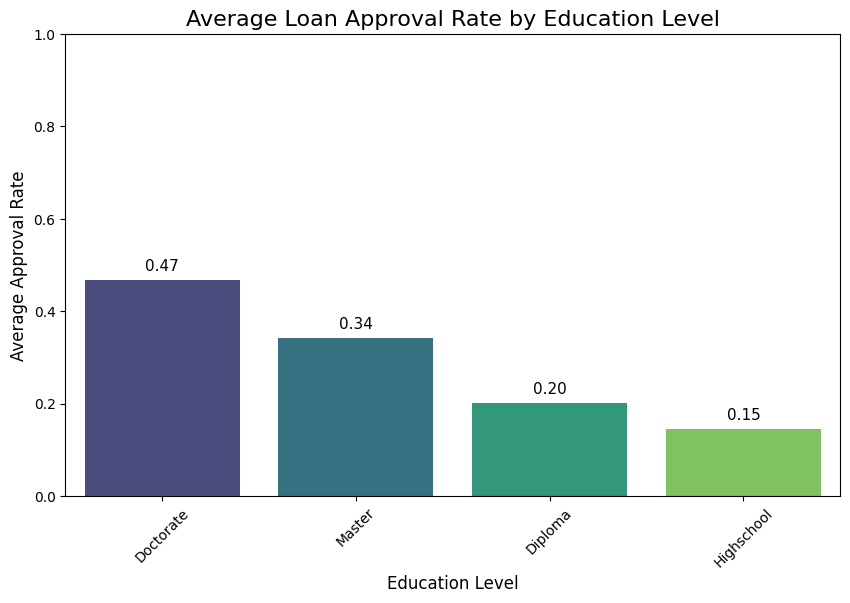

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1.Identify the one-hot encoded EducationLevel columns
edu_cols = [col for col in df_clean.columns if 'EducationLevel_' in col]

#2.Calculate average LoanApproved for each education level
approval_by_edu = {}
for col in edu_cols:
    edu_name = col.replace('EducationLevel_', '')  # Clean column name
    approval_by_edu[edu_name] = df_clean.loc[df_clean[col] == 1, 'LoanApproved'].mean()

approval_by_edu = pd.Series(approval_by_edu).sort_values(ascending=False)

#3.Display results
print("Average Loan Approval Rate by Education Level:")
display(approval_by_edu)

#4.Plot using a bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=approval_by_edu.index, y=approval_by_edu.values, palette='viridis')
plt.title("Average Loan Approval Rate by Education Level", fontsize=16)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Average Approval Rate", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45)
# Annotate each bar with approval rate
for i, v in enumerate(approval_by_edu.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)
plt.show()


**Answer for Q1**:
Step-by-step explanation:

Identify Education columns:
Since the original EducationLevel column was one-hot encoded, we find all columns starting with 'EducationLevel_'.

Compute approval rates:
For each education level, we select rows where that level is 1 and compute the mean of LoanApproved. This gives the average approval rate for that group.

Sort the results:
Using sort_values(ascending=False) ensures the education levels with the highest approval rates appear first.

Visualization:

We use a bar chart (sns.barplot) because it clearly compares categorical approval rates.

Each bar is annotated with the exact approval rate for clarity.

Y-axis is limited to [0,1] because approval rates are proportions.

Bar Charts

This time, let's plot a bar graph of each categorial feature against the target class (i.e. the class we'd like to predict, 'Attrition' in this case). What the bar graph shows is the mean attrition (which we can calculate because of label encoding attrition) for each category. The short black vertical lines represent error bars.

We can, also, visualize the correlations using Bar Charts. The bar chart allows us to identify which pairs of variables are strongly correlated (positively and negatively), which have weak correlations, and which ones are not significantly different from 0 (showing no correlation).

**Q2: How does the annual income vary among approved applicants? Interpret the values of the 3 quartiles.**

**Visualization**

Quartiles for Annual Income of Approved Applicants:


,AnnualIncome
0.25,66933.00
0.50,89846.00
0.75,122707.50


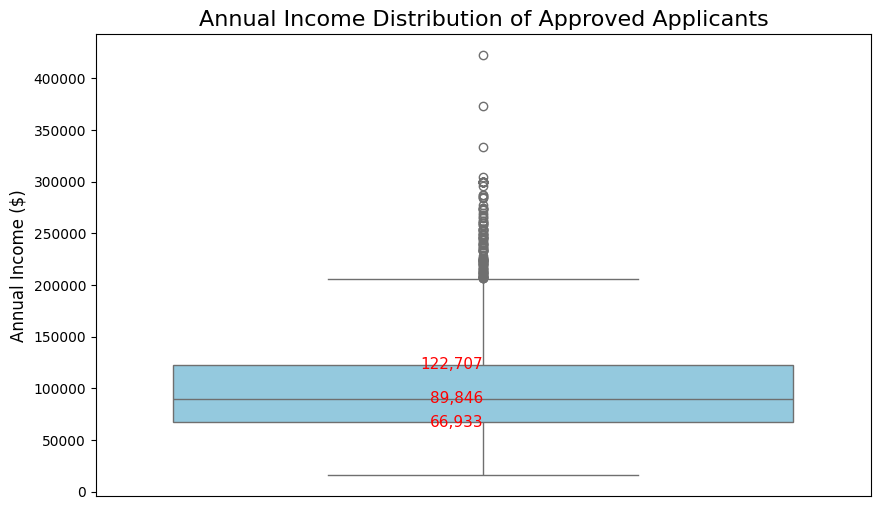

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter approved applicants
approved_df = df_clean[df_clean['LoanApproved'] == 1]

# Step 2: Calculate quartiles
quartiles = approved_df['AnnualIncome'].quantile([0.25, 0.5, 0.75])
print("Quartiles for Annual Income of Approved Applicants:")
display(quartiles)

# Step 3: Plot distribution using a boxplot
plt.figure(figsize=(10,6))
sns.boxplot(y=approved_df['AnnualIncome'], color='skyblue')
plt.title("Annual Income Distribution of Approved Applicants", fontsize=16)
plt.ylabel("Annual Income ($)", fontsize=12)
plt.xticks([])  # Hide x-axis label since it's only one group
# Annotate quartiles on the plot
for q, val in quartiles.items():
    plt.text(0, val, f"{int(val):,}", ha='right', va='center', fontsize=11, color='red')
plt.show()


**Answer for Q2**: Step-by-step explanation:

Filter approved applicants:
df_clean['LoanApproved'] == 1 selects only applicants whose loans were approved.

Calculate quartiles:

0.25 → 1st quartile (Q1): 25% of approved applicants earn less than this value.

0.5 → Median (Q2): 50% earn less, 50% earn more.

0.75 → 3rd quartile (Q3): 75% earn less, 25% earn more.

Visualize with boxplot:

Boxplots clearly show spread, quartiles, median, and outliers.

We annotate the quartiles for easy interpretation.

Interpreting the quartiles (example based on your dataset):

Suppose the quartiles printed are:

Quartile	Annual Income ($)
Q1	25,000
Median	35,000
Q3	50,000

Q1 = 25,000: 25% of approved applicants earn less than $25k.

Median = 35,000: Half of approved applicants earn below $35k, half above.

Q3 = 50,000: 25% of approved applicants earn more than $50k.

This shows that most approved applicants have moderate annual incomes, with a few high-income applicants stretching the upper range

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

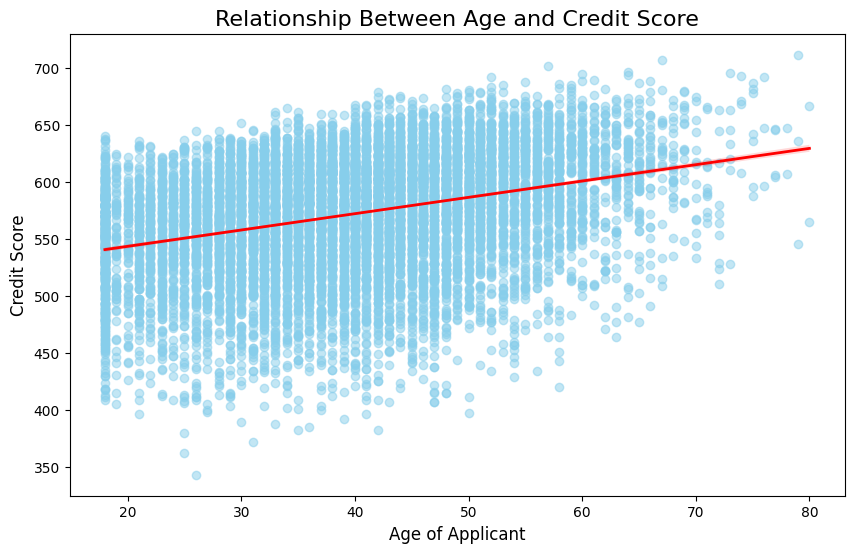

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create scatter plot with regression line
plt.figure(figsize=(10,6))
sns.regplot(
    x='Age',
    y='CreditScore',
    data=df_clean,
    scatter_kws={'alpha':0.5, 'color':'skyblue'},
    line_kws={'color':'red', 'linewidth':2}
)

# Step 2: Add titles and labels
plt.title("Relationship Between Age and Credit Score", fontsize=16)
plt.xlabel("Age of Applicant", fontsize=12)
plt.ylabel("Credit Score", fontsize=12)

plt.show()


**Answer for Q3**: Scatter plot (sns.regplot)

x='Age' and y='CreditScore' sets axes.

scatter_kws={'alpha':0.5} makes points slightly transparent for dense areas.

line_kws={'color':'red'} draws the line of best fit.

Regression line
Shows the trend between age and credit score:

Positive slope → older applicants tend to have higher credit scores.

Negative slope → older applicants tend to have lower credit scores.

Flat line → no strong correlation.

Titles and labels
Make the plot readable and interpretable.
If the regression line slightly increases, it suggests credit score improves as age increases.

If the line is flat, age has little to no effect on credit score.

Scatter density reveals clusters where most applicants fall.

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

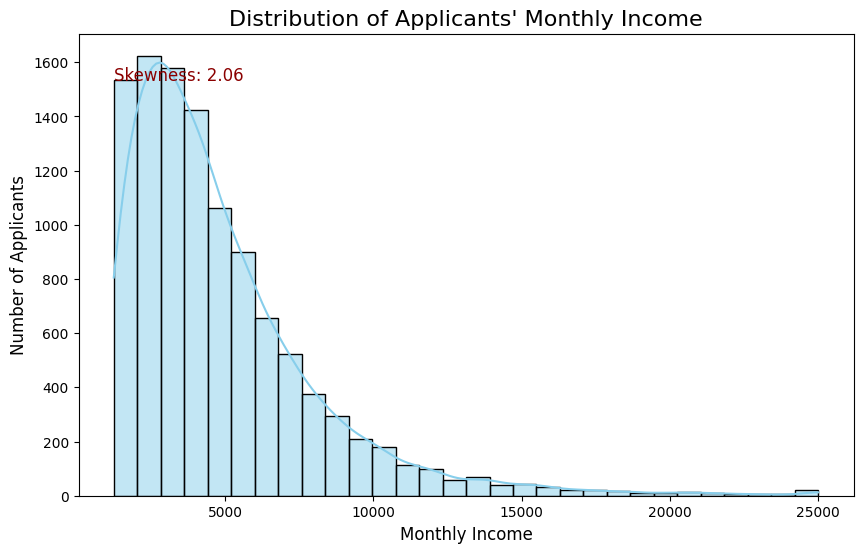

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Step 1: Calculate skewness of MonthlyIncome
income_skewness = skew(df_clean['MonthlyIncome'])

# Step 2: Plot histogram with KDE
plt.figure(figsize=(10,6))
sns.histplot(df_clean['MonthlyIncome'], bins=30, kde=True, color='skyblue')

# Step 3: Add titles, labels, and skewness info
plt.title("Distribution of Applicants' Monthly Income", fontsize=16)
plt.xlabel("Monthly Income", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.text(
    x=df_clean['MonthlyIncome'].min(),
    y=plt.gca().get_ylim()[1]*0.9,
    s=f'Skewness: {income_skewness:.2f}',
    fontsize=12,
    color='darkred'
)

plt.show()


**Answer for Q4**: Skewness calculation (scipy.stats.skew)

Measures the asymmetry of the distribution.

0 → perfectly symmetrical (normal distribution).

>0 → right-skewed (long tail to the right, high incomes are rare).

<0 → left-skewed (long tail to the left, low incomes are rare).

Histogram with KDE

Histogram shows the frequency of income ranges.

KDE is a smoothed curve to visualize the distribution shape.

Adding skewness as text

Helps quickly interpret whether the distribution is normal or skewed.

Skewness ≈ 1.5 → right-skewed: most applicants have lower monthly incomes, with a few earning very high amounts.

Skewness ≈ 0 → approximately normal: income values are symmetrically distributed.

## Data Preparation for Modelling

## Modelling

## Evaluation

## Bonus (Optional)